## Car price dataset

```
Om Choksi
23AIML010

```

### Import Libraries

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.pipeline import Pipeline

from sklearn.compose import ColumnTransformer


import warnings as w
w.filterwarnings

<function warnings.filterwarnings(action, message='', category=<class 'Warning'>, module='', lineno=0, append=False)>

### Load Dataset

In [2]:
df = pd.read_csv('/kaggle/input/car-price-dataset/car_price.csv')
df.head()

,CarName,carbody,drivewheel,enginelocation,fueltype,aspiration,doornumber,cylindernumber,enginetype,fuelsystem,...,curbweight,enginesize,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,alfa-romero giulia,convertible,rwd,front,gas,std,two,four,dohc,mpfi,...,2548,130,3.47,2.68,9.0,111,5000,21,27,13495.0
1,alfa-romero stelvio,convertible,rwd,front,gas,std,two,four,dohc,mpfi,...,2548,130,3.47,2.68,9.0,111,5000,21,27,16500.0
2,alfa-romero Quadrifoglio,hatchback,rwd,front,gas,std,two,six,ohcv,mpfi,...,2823,152,2.68,3.47,9.0,154,5000,19,26,16500.0
3,audi 100 ls,sedan,fwd,front,gas,std,four,four,ohc,mpfi,...,2337,109,3.19,3.40,10.0,102,5500,24,30,13950.0
4,audi 100ls,sedan,4wd,front,gas,std,four,five,ohc,mpfi,...,2824,136,3.19,3.40,8.0,115,5500,18,22,17450.0


### Data Spread

In [3]:
df.columns

Index(['CarName', 'carbody', 'drivewheel', 'enginelocation', 'fueltype',
       'aspiration', 'doornumber', 'cylindernumber', 'enginetype',
       'fuelsystem', 'symboling', 'wheelbase', 'carlength', 'carwidth',
       'carheight', 'curbweight', 'enginesize', 'boreratio', 'stroke',
       'compressionratio', 'horsepower', 'peakrpm', 'citympg', 'highwaympg',
       'price'],
      dtype='object')

In [4]:
df.shape[0],df.shape[1]

(210, 25)

#### remove duplicates

In [5]:
df= df.drop_duplicates()

In [6]:
df.describe()

,symboling,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
count,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000
mean,0.834146,98.756585,174.049268,65.907805,53.724878,2555.565854,126.907317,3.329756,3.255415,10.142537,104.117073,5125.121951,25.219512,30.751220,13276.710571
std,1.245307,6.021776,12.337289,2.145204,2.443522,520.680204,41.642693,0.270844,0.313597,3.972040,39.544167,476.985643,6.542142,6.886443,7988.852332
min,-2.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,2.540000,2.070000,7.000000,48.000000,4150.000000,13.000000,16.000000,5118.000000
25%,0.000000,94.500000,166.300000,64.100000,52.000000,2145.000000,97.000000,3.150000,3.110000,8.600000,70.000000,4800.000000,19.000000,25.000000,7788.000000
50%,1.000000,97.000000,173.200000,65.500000,54.100000,2414.000000,120.000000,3.310000,3.290000,9.000000,95.000000,5200.000000,24.000000,30.000000,10295.000000
75%,2.000000,102.400000,183.100000,66.900000,55.500000,2935.000000,141.000000,3.580000,3.410000,9.400000,116.000000,5500.000000,30.000000,34.000000,16503.000000
max,3.000000,120.900000,208.100000,72.300000,59.800000,4066.000000,326.000000,3.940000,4.170000,23.000000,288.000000,6600.000000,49.000000,54.000000,45400.000000


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 205 entries, 0 to 204
Data columns (total 25 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   CarName           205 non-null    object 
 1   carbody           205 non-null    object 
 2   drivewheel        205 non-null    object 
 3   enginelocation    205 non-null    object 
 4   fueltype          205 non-null    object 
 5   aspiration        205 non-null    object 
 6   doornumber        205 non-null    object 
 7   cylindernumber    205 non-null    object 
 8   enginetype        205 non-null    object 
 9   fuelsystem        205 non-null    object 
 10  symboling         205 non-null    int64  
 11  wheelbase         205 non-null    float64
 12  carlength         205 non-null    float64
 13  carwidth          205 non-null    float64
 14  carheight         205 non-null    float64
 15  curbweight        205 non-null    int64  
 16  enginesize        205 non-null    int64  
 17  bo

#### Finding null values

In [8]:
df.isnull().sum()

CarName             0
carbody             0
drivewheel          0
enginelocation      0
fueltype            0
aspiration          0
doornumber          0
cylindernumber      0
enginetype          0
fuelsystem          0
symboling           0
wheelbase           0
carlength           0
carwidth            0
carheight           0
curbweight          0
enginesize          0
boreratio           0
stroke              0
compressionratio    0
horsepower          0
peakrpm             0
citympg             0
highwaympg          0
price               0
dtype: int64

### Data Prepration 

In [9]:
# Target
target = 'price'

In [10]:

# Categorical and Numerical columns
cat_cols = df.select_dtypes(include='object').columns.tolist()
num_cols = df.select_dtypes(exclude='object').columns.tolist()

In [11]:
# Remove target from numerical list
num_cols.remove(target)
num_cols

['symboling',
 'wheelbase',
 'carlength',
 'carwidth',
 'carheight',
 'curbweight',
 'enginesize',
 'boreratio',
 'stroke',
 'compressionratio',
 'horsepower',
 'peakrpm',
 'citympg',
 'highwaympg']

In [12]:
cat_cols

['CarName',
 'carbody',
 'drivewheel',
 'enginelocation',
 'fueltype',
 'aspiration',
 'doornumber',
 'cylindernumber',
 'enginetype',
 'fuelsystem']

In [13]:
# Extract brand name
df['brand'] = df['CarName'].apply(lambda x: x.split(' ')[0].lower())
df['brand'].sample(5)

83     mitsubishi
144        subaru
119      plymouth
20      chevrolet
12            bmw
Name: brand, dtype: object

In [14]:
# Drop CarName
df.drop(columns=['CarName'], inplace=True)

In [15]:
# Update categorical columns
cat_cols.remove('CarName')
cat_cols.append('brand')

df[['brand']].head()

,brand
0,alfa-romero
1,alfa-romero
2,alfa-romero
3,audi
4,audi


In [16]:
brand_corrections = {
    'vw': 'volkswagen',
    'vokswagen': 'volkswagen',
    'maxda': 'mazda',
    'porcshce': 'porsche',
    'toyouta': 'toyota'
}

df['brand'] = df['brand'].replace(brand_corrections)
df['brand'].value_counts().head(10)


brand
toyota        32
nissan        18
mazda         17
mitsubishi    13
honda         13
subaru        12
volkswagen    12
volvo         11
peugeot       11
dodge          9
Name: count, dtype: int64

In [17]:
door_map = {'two': 2, 'four': 4}
cylinder_map = {
    'two': 2, 'three': 3, 'four': 4,
    'five': 5, 'six': 6,
    'eight': 8, 'twelve': 12
}

In [18]:
df['doornumber'] = df['doornumber'].map(door_map)

In [19]:
df['cylindernumber'] = df['cylindernumber'].map(cylinder_map)

In [20]:
df[['doornumber', 'cylindernumber']].head()

,doornumber,cylindernumber
0,2,4
1,2,4
2,2,6
3,4,4
4,4,5


#### Re-classify columns after cleaning

In [21]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
num_cols = df.select_dtypes(exclude='object').columns.tolist()
num_cols.remove(target)

cat_cols,num_cols


(['carbody',
  'drivewheel',
  'enginelocation',
  'fueltype',
  'aspiration',
  'enginetype',
  'fuelsystem',
  'brand'],
 ['doornumber',
  'cylindernumber',
  'symboling',
  'wheelbase',
  'carlength',
  'carwidth',
  'carheight',
  'curbweight',
  'enginesize',
  'boreratio',
  'stroke',
  'compressionratio',
  'horsepower',
  'peakrpm',
  'citympg',
  'highwaympg'])

### EDA

#### Univariate analysis

#### Outliers detection

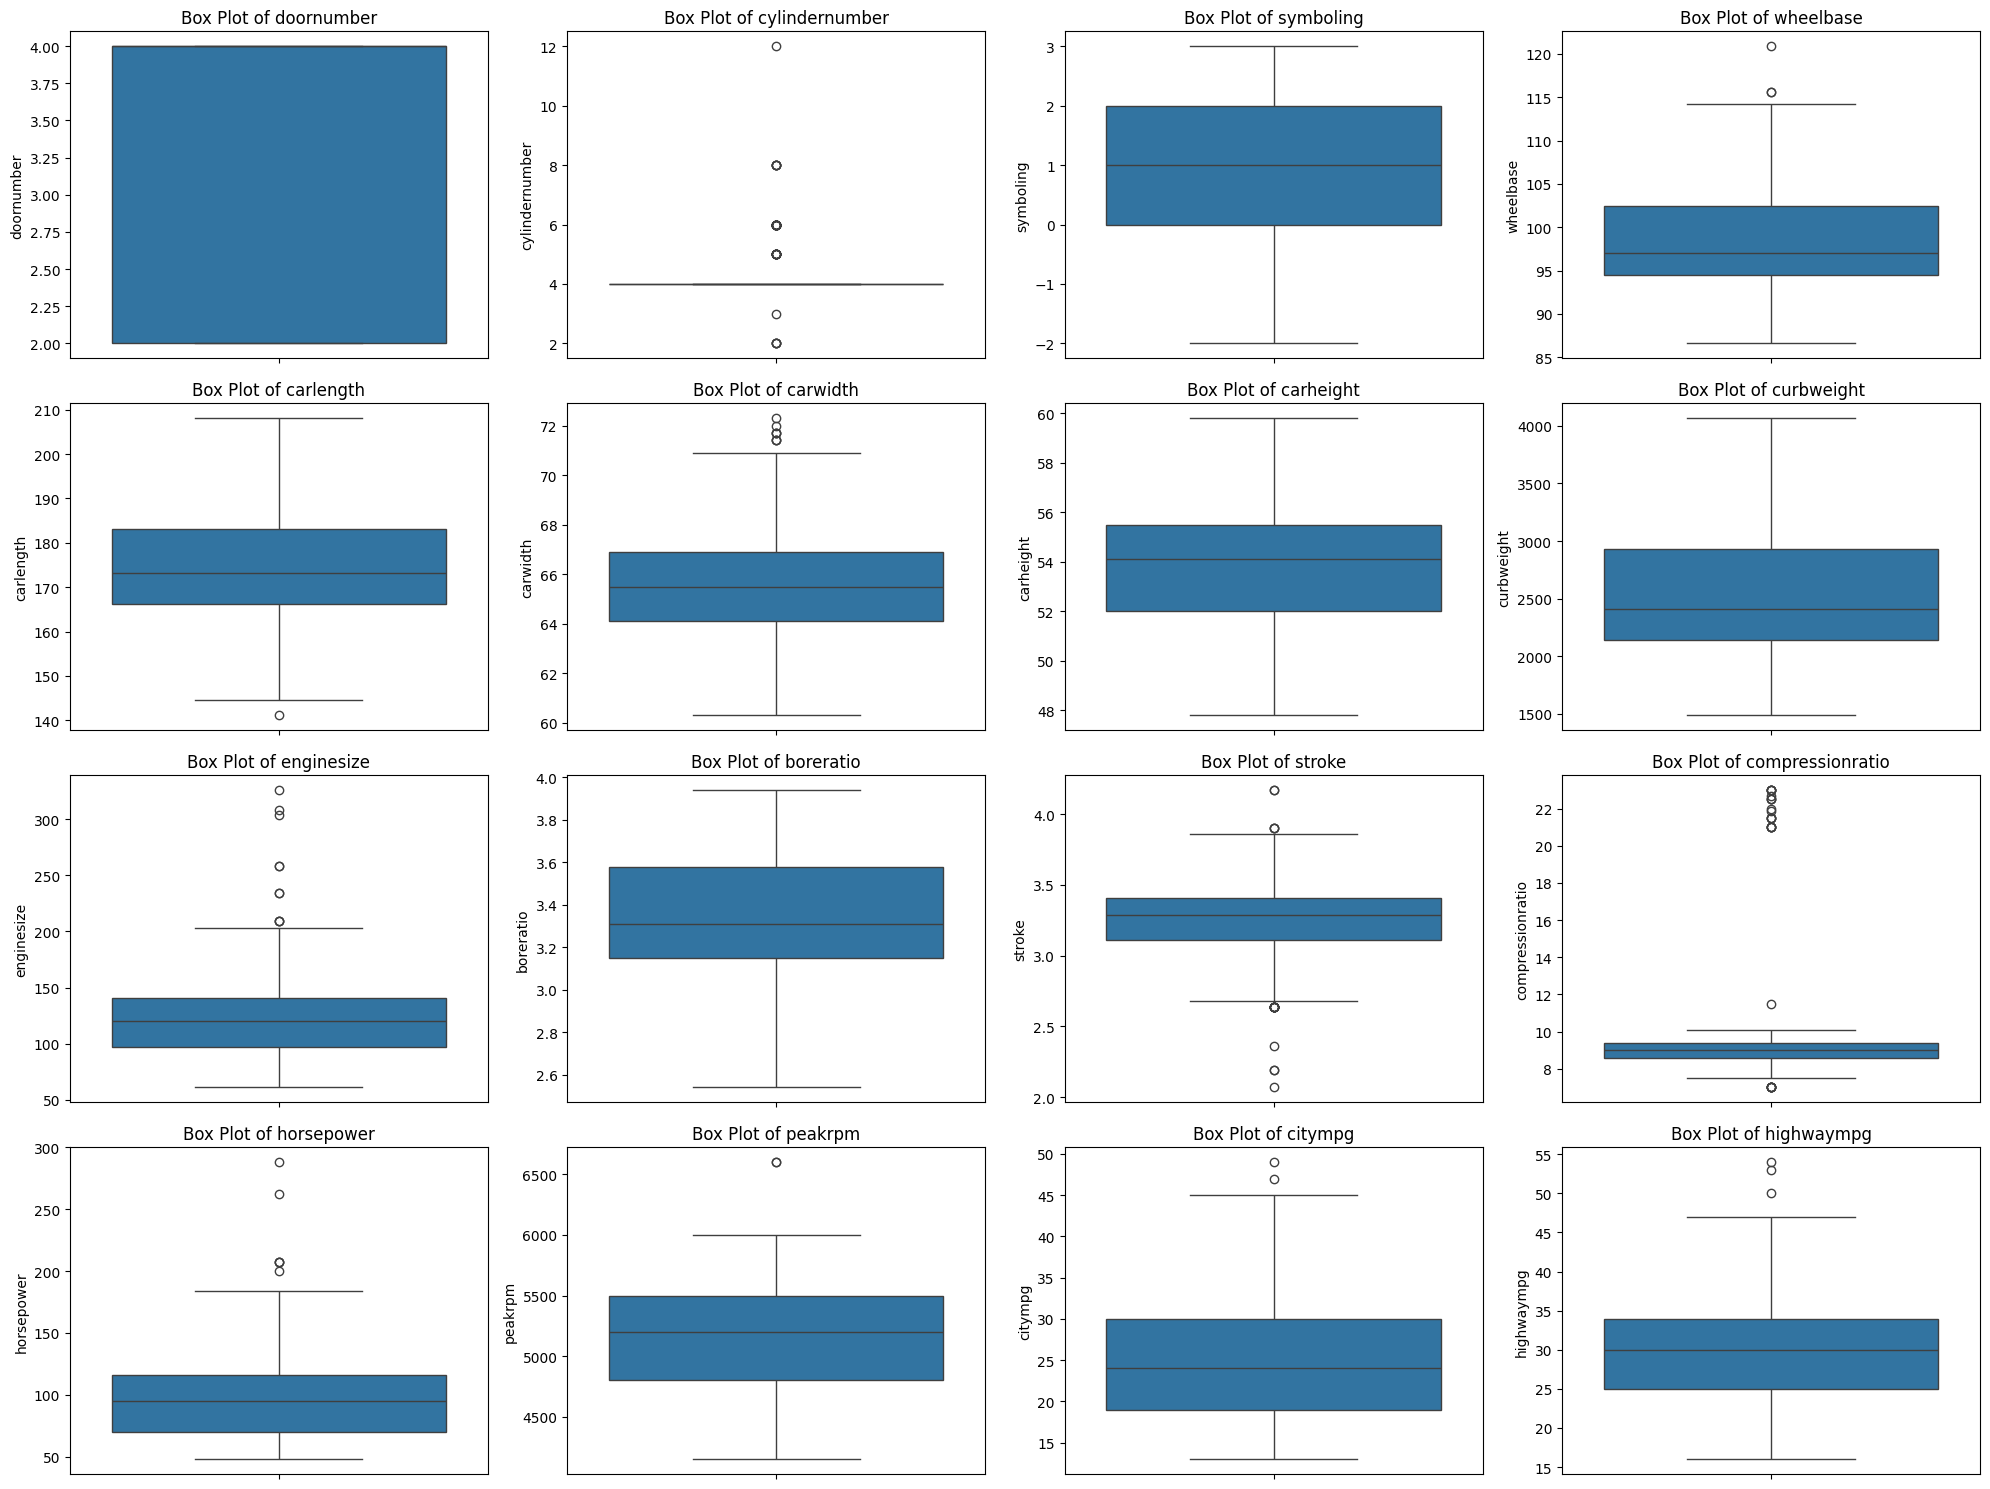

In [22]:
plt.figure(figsize=(20, 15))
for i, col in enumerate(num_cols):
    if col != 'price': # Exclude price for distribution plot as it's our target variable
        plt.subplot(4, 4, i + 1) # Adjust subplot grid as needed
        sns.boxplot(y=df[col])
        plt.title(f'Box Plot of {col}')
        plt.ylabel(col)
plt.tight_layout()
plt.show()



#### check for skewness

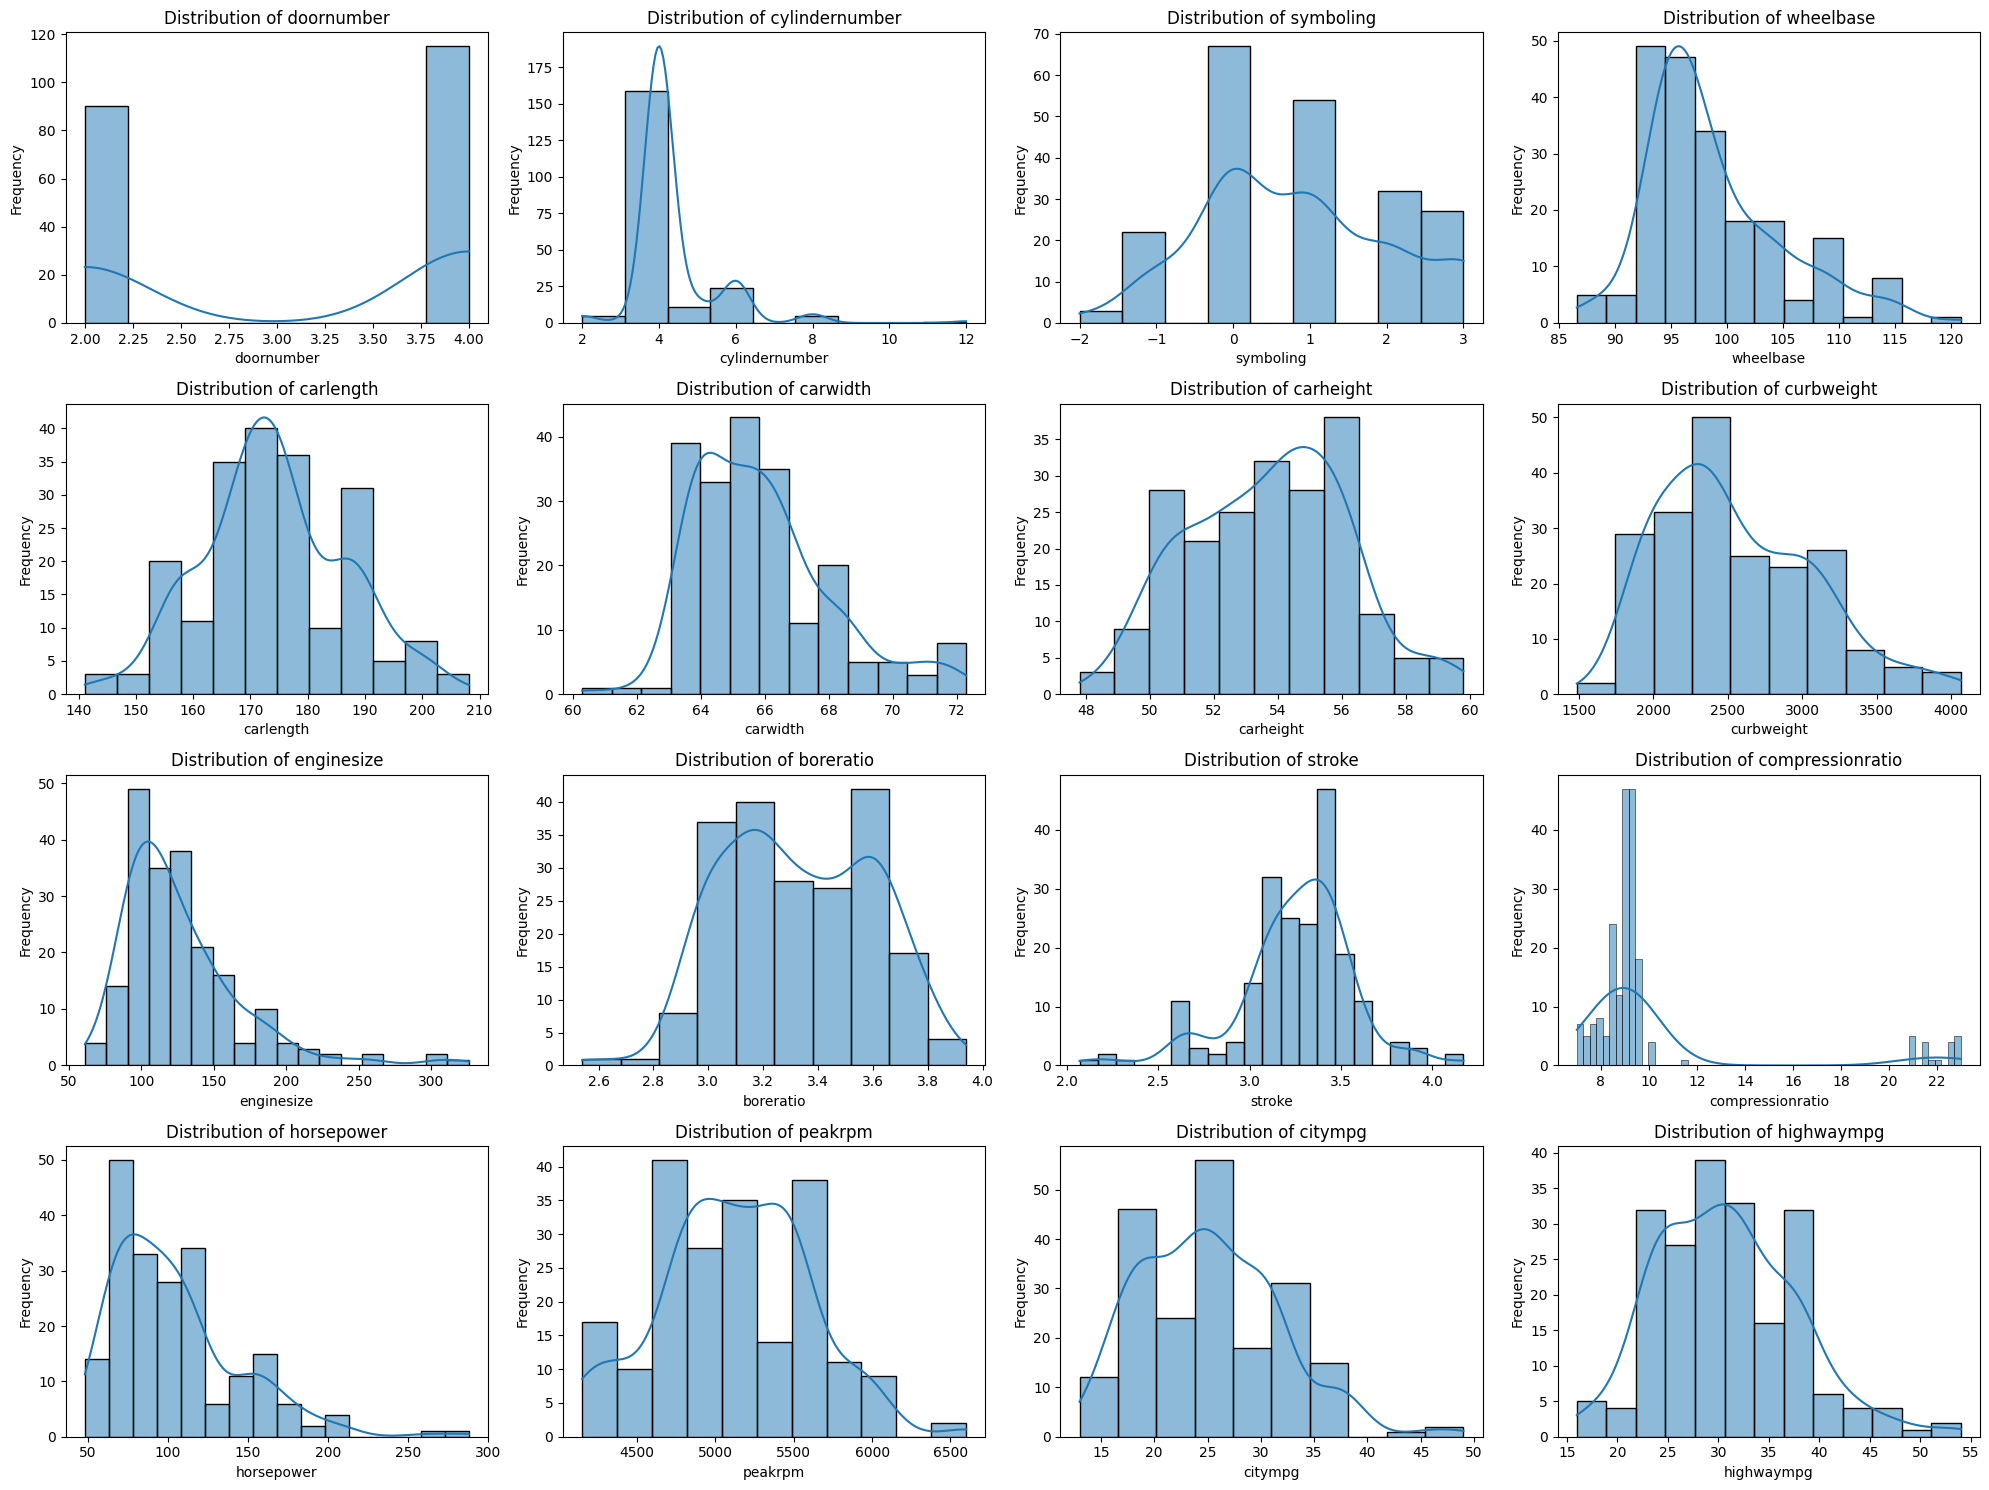

In [23]:
# Analyze Numerical Feature Distributions
plt.figure(figsize=(20, 15))
for i, col in enumerate(num_cols):
    if col != 'price':
        plt.subplot(4, 4, i + 1)
        sns.histplot(df[col], kde=True)
        plt.title(f'Distribution of {col}')
        plt.xlabel(col)
        plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

In [24]:
skew_df = df[num_cols + ['price']].skew().sort_values(ascending=False)
skew_df


cylindernumber      2.817459
compressionratio    2.610862
enginesize          1.947655
price               1.777678
horsepower          1.405310
wheelbase           1.050214
carwidth            0.904003
curbweight          0.681398
citympg             0.663704
highwaympg          0.539997
symboling           0.211072
carlength           0.155954
peakrpm             0.075159
carheight           0.063123
boreratio           0.020156
doornumber         -0.247552
stroke             -0.689705
dtype: float64

#### target variable

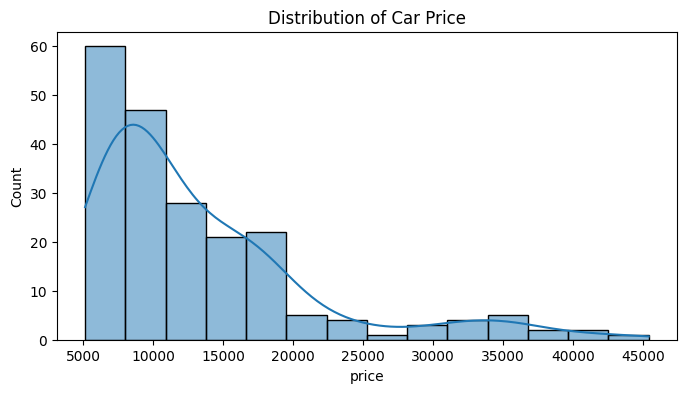

count      205.000000
mean     13276.710571
std       7988.852332
min       5118.000000
25%       7788.000000
50%      10295.000000
75%      16503.000000
max      45400.000000
Name: price, dtype: float64

In [25]:
plt.figure(figsize=(8,4))
sns.histplot(df['price'], kde=True)
plt.title("Distribution of Car Price")
plt.show()

df['price'].describe()

#### Categorical feature

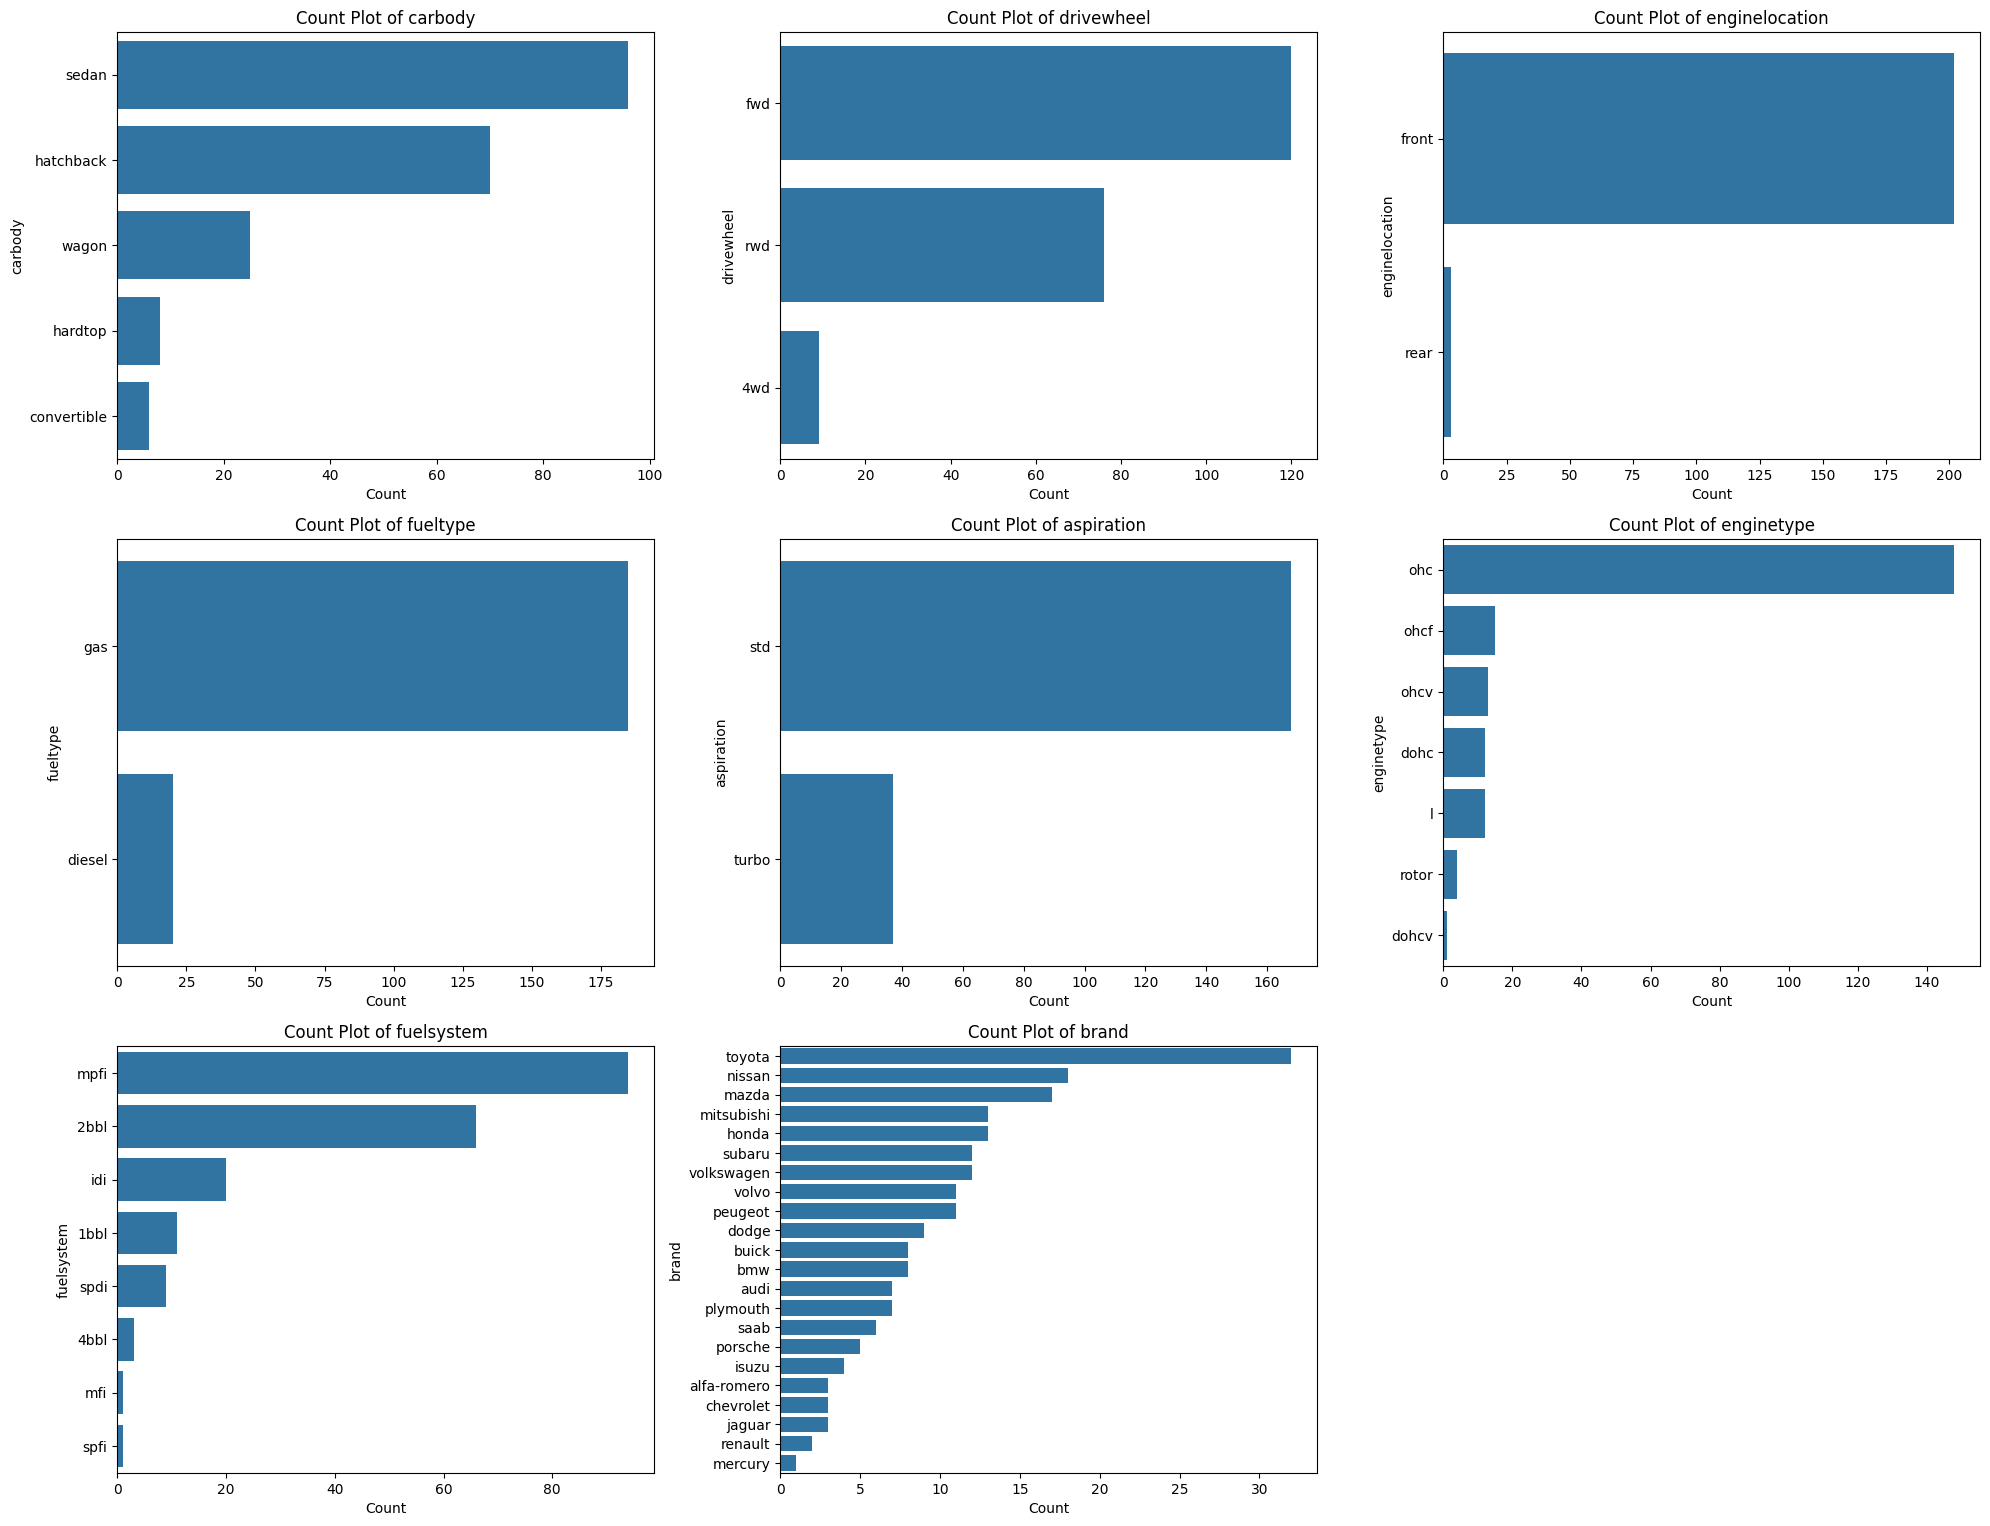

In [26]:
plt.figure(figsize=(20, 20))
for i, col in enumerate(cat_cols):
    plt.subplot(4, 3, i + 1) # Adjust subplot grid as needed
    sns.countplot(y=df[col], order = df[col].value_counts().index)
    plt.title(f'Count Plot of {col}')
    plt.xlabel('Count')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

#### Numerical feature

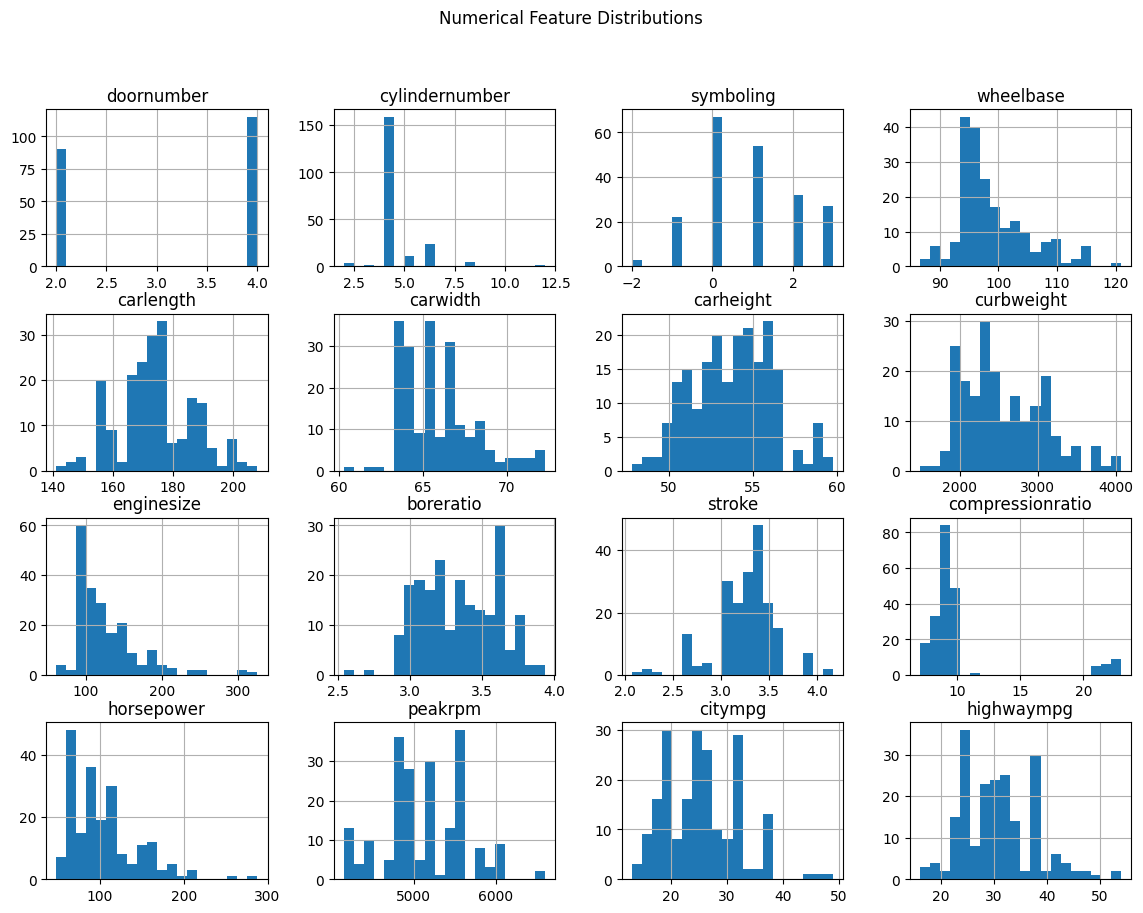

In [27]:
df[num_cols].hist(figsize=(14,10), bins=20)
plt.suptitle("Numerical Feature Distributions")
plt.show()


### Bivariate analysis 

#### Price vs categorical features

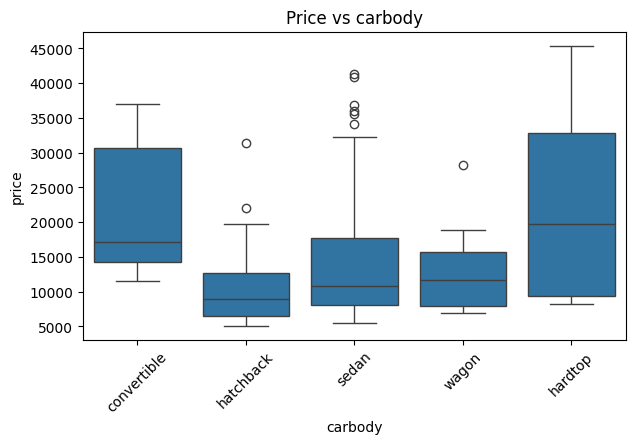

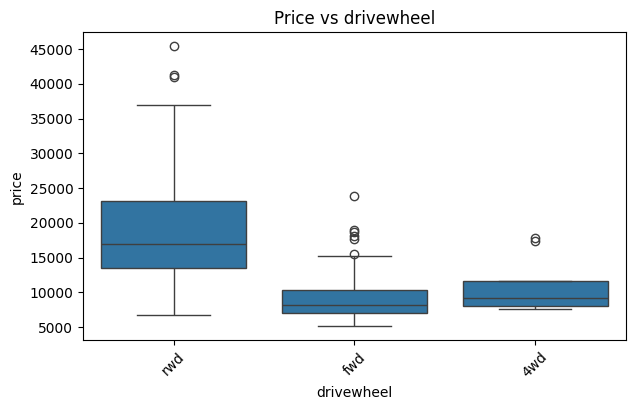

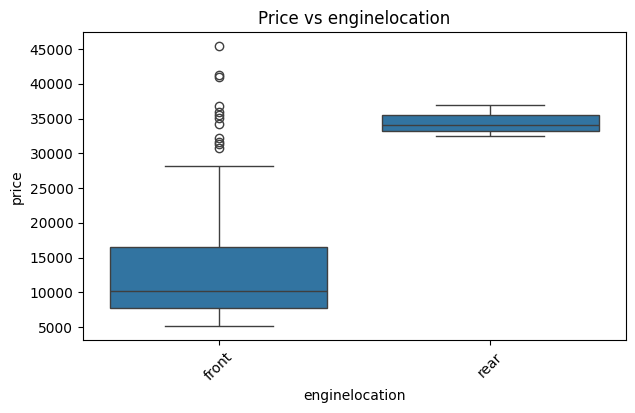

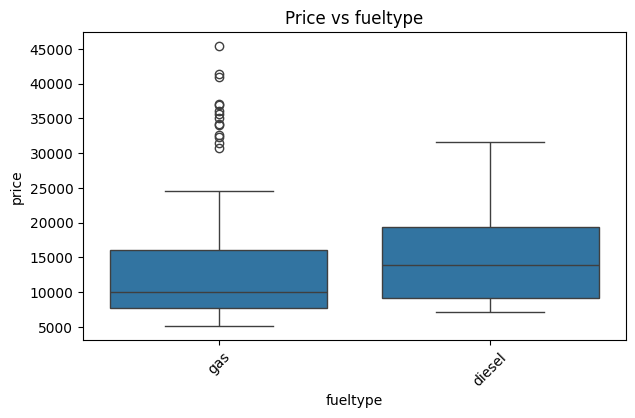

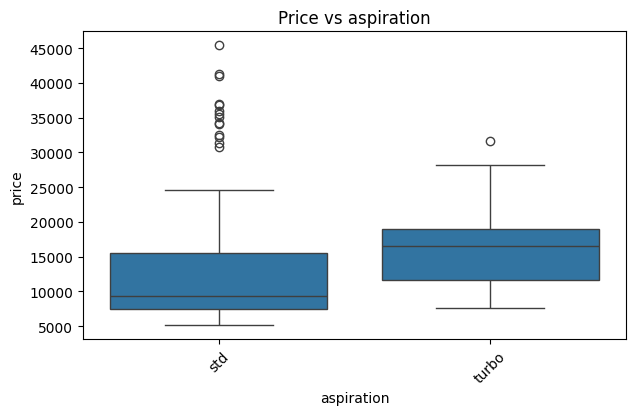

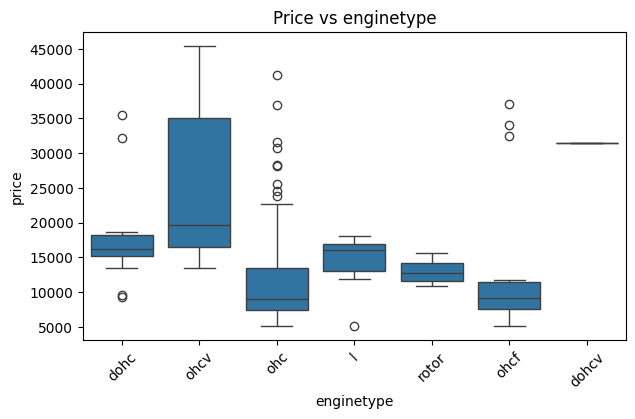

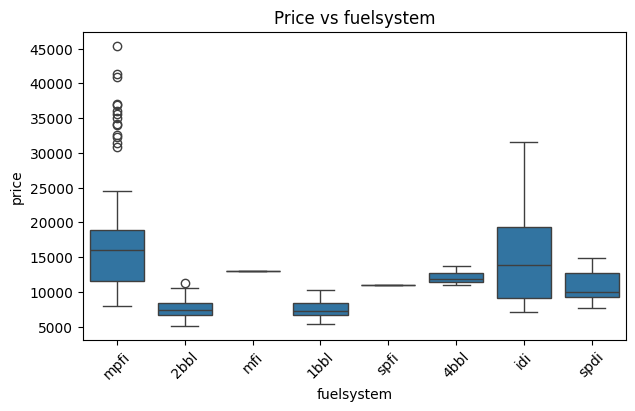

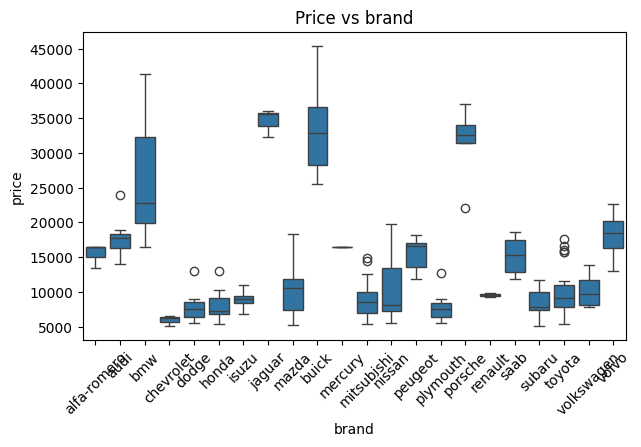

In [28]:
for col in cat_cols:
    plt.figure(figsize=(7,4))
    sns.boxplot(x=col, y='price', data=df)
    plt.xticks(rotation=45)
    plt.title(f"Price vs {col}")
    plt.show()


#### Price vs numerical features (core EDA)

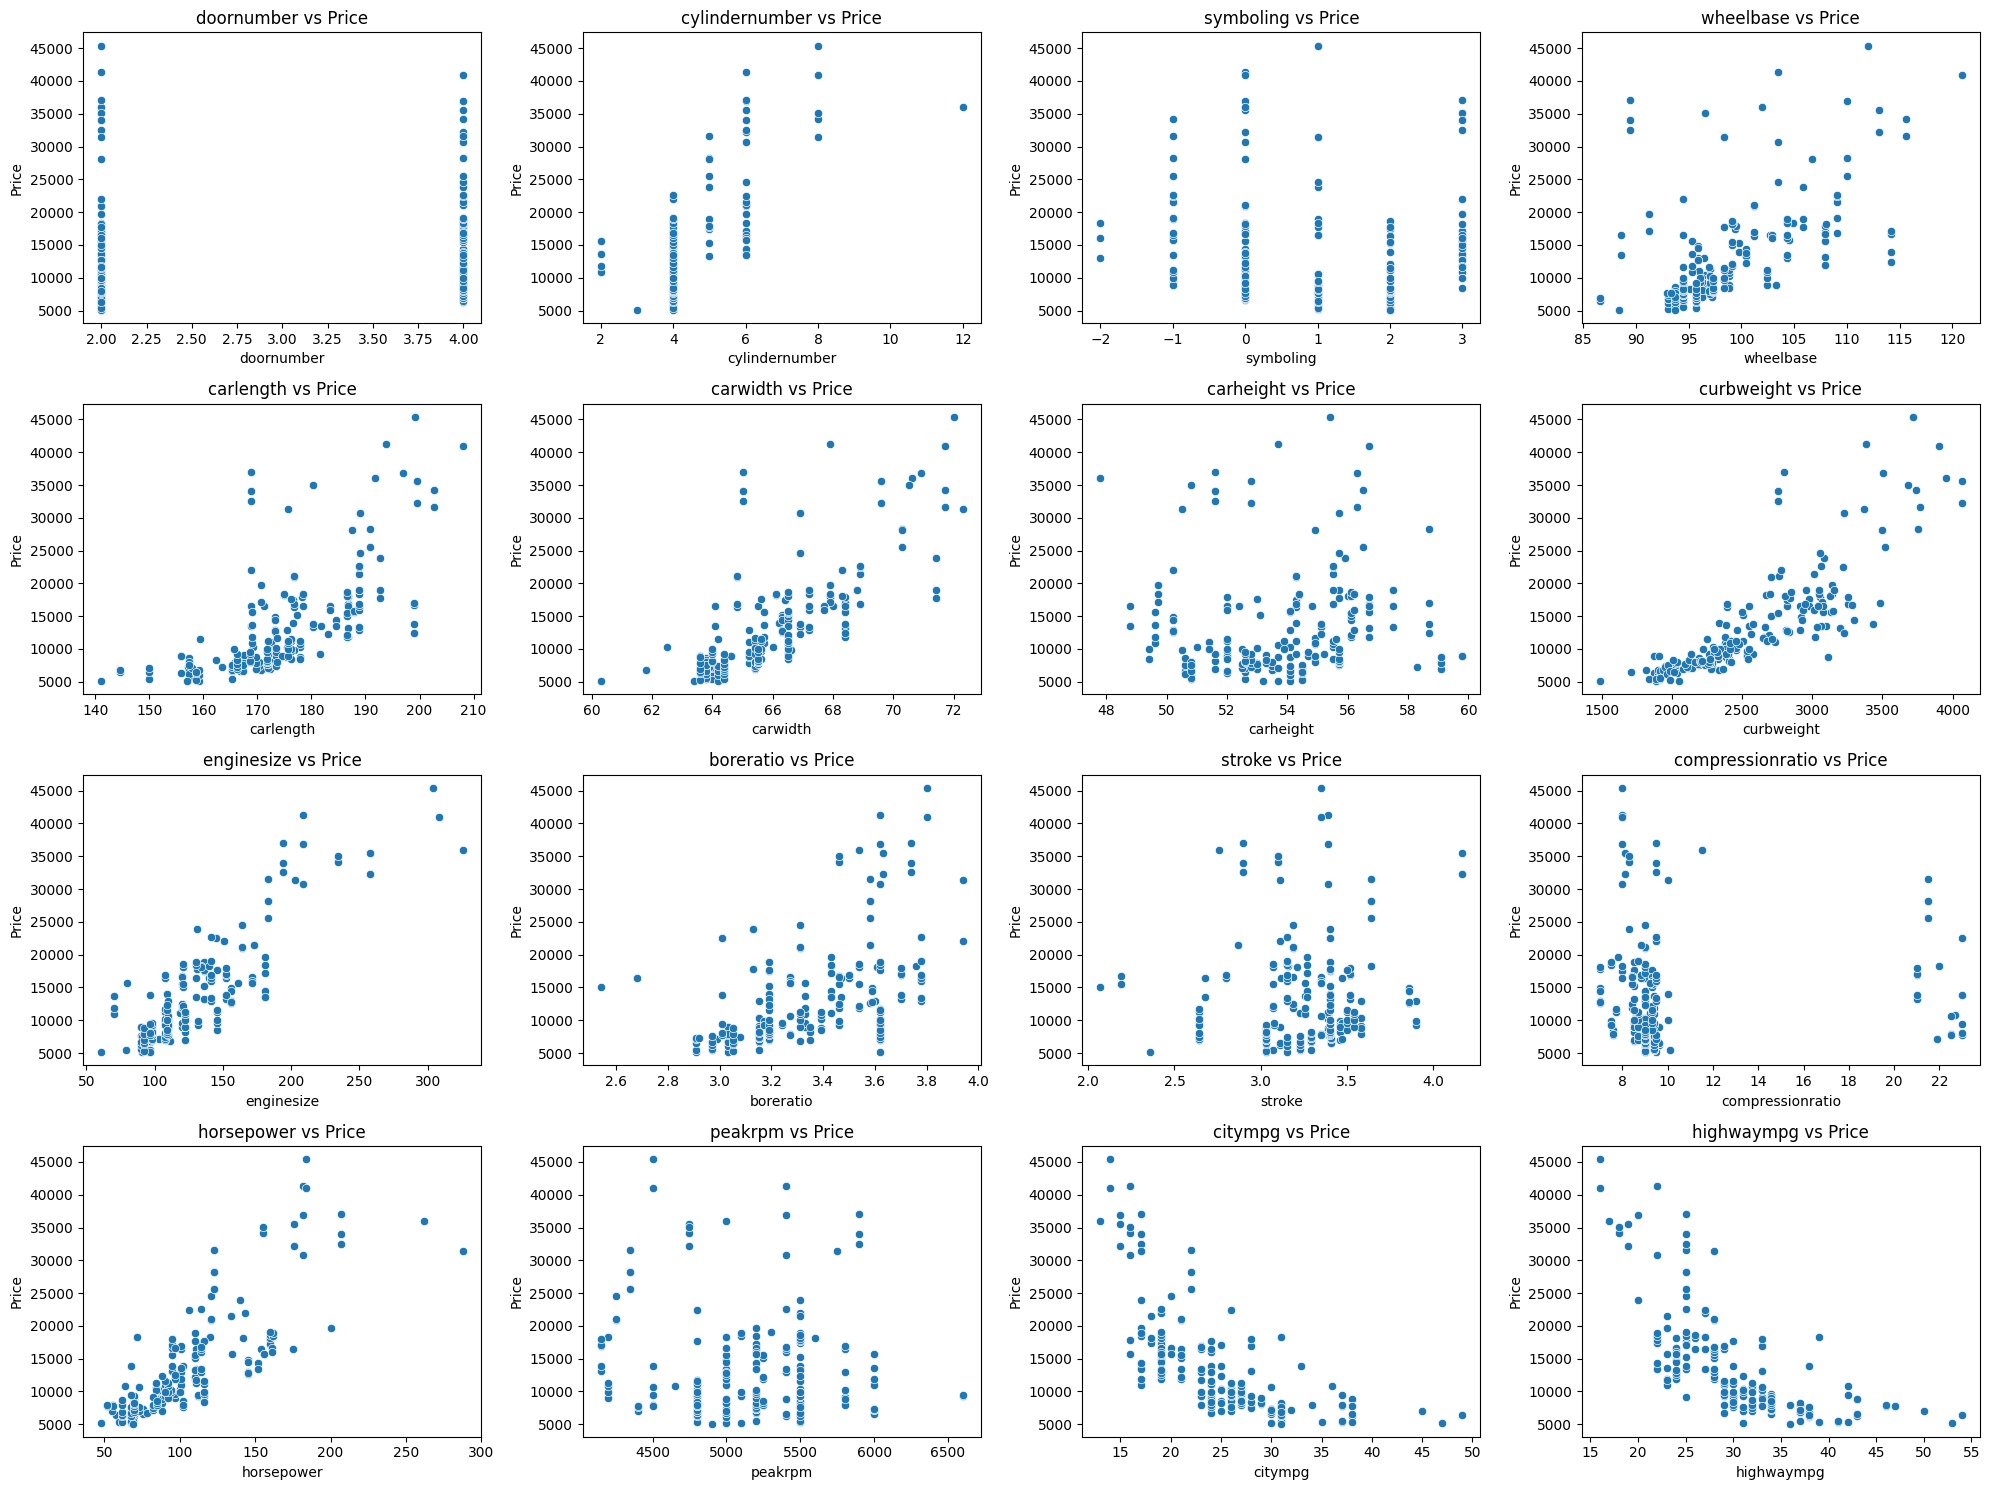

In [29]:
plt.figure(figsize=(20, 15))
for i, col in enumerate(num_cols):
    if col != 'price':
        plt.subplot(4, 4, i + 1) # Adjust subplot grid as needed
        sns.scatterplot(x=df[col], y=df['price'])
        plt.title(f'{col} vs Price')
        plt.xlabel(col)
        plt.ylabel('Price')
plt.tight_layout()
plt.show()

#### Correlation heatmap

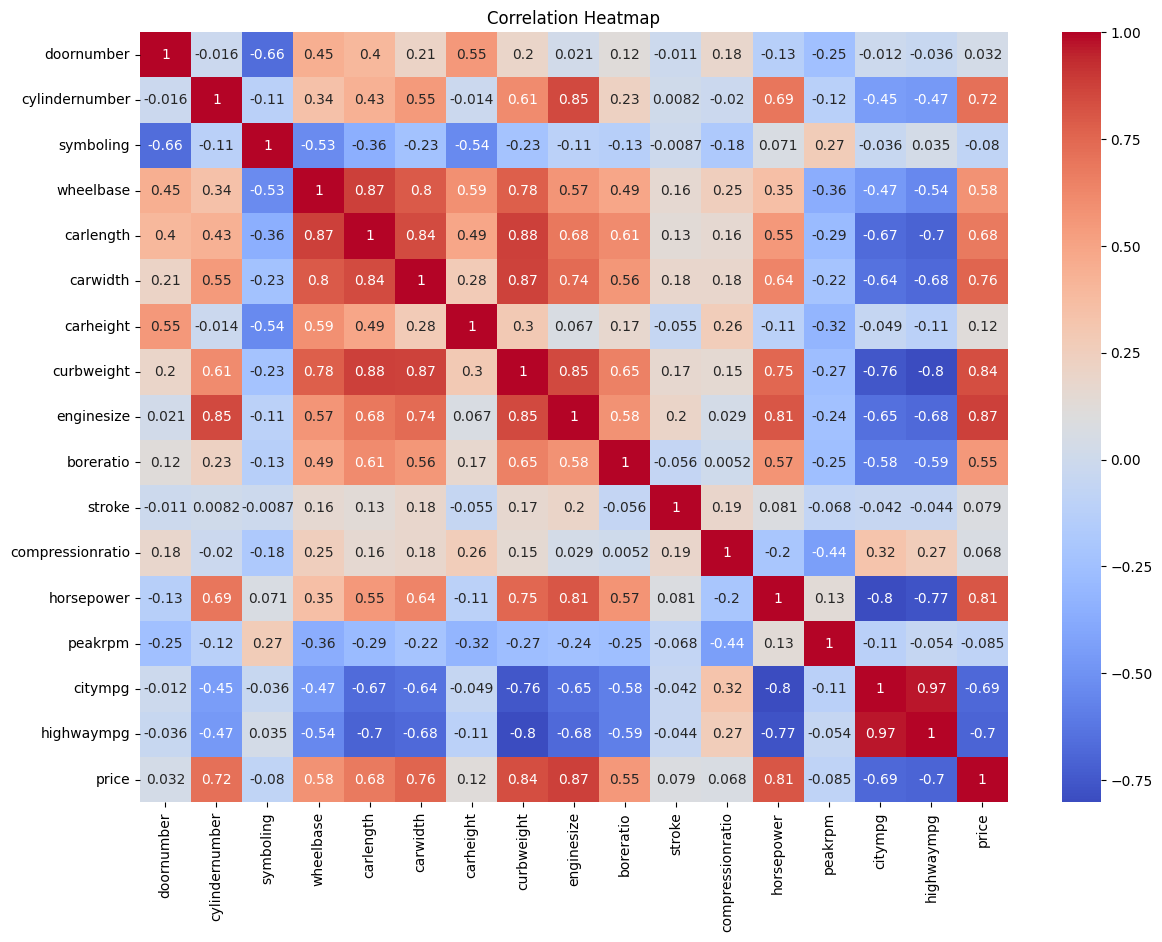

In [30]:
plt.figure(figsize=(14,10))
corr = df[num_cols + ['price']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


In [31]:
corr_price = corr['price'].sort_values(ascending=False)
corr_price

price               1.000000
enginesize          0.874145
curbweight          0.835305
horsepower          0.808139
carwidth            0.759325
cylindernumber      0.718305
carlength           0.682920
wheelbase           0.577816
boreratio           0.553173
carheight           0.119336
stroke              0.079443
compressionratio    0.067984
doornumber          0.031835
symboling          -0.079978
peakrpm            -0.085267
citympg            -0.685751
highwaympg         -0.697599
Name: price, dtype: float64

#### Log Transformation

In [32]:

skewed_features = skew_df[abs(skew_df) > 1].index.tolist()
skewed_features.remove('price')  # target handled separately

for col in skewed_features:
    df[col] = np.log1p(df[col])


In [33]:

# Cap extreme price values (winsorization)
lower = df['price'].quantile(0.01)
upper = df['price'].quantile(0.99)
df['price'] = df['price'].clip(lower, upper)

# Log-transform target only
df['price_log'] = np.log1p(df['price'])


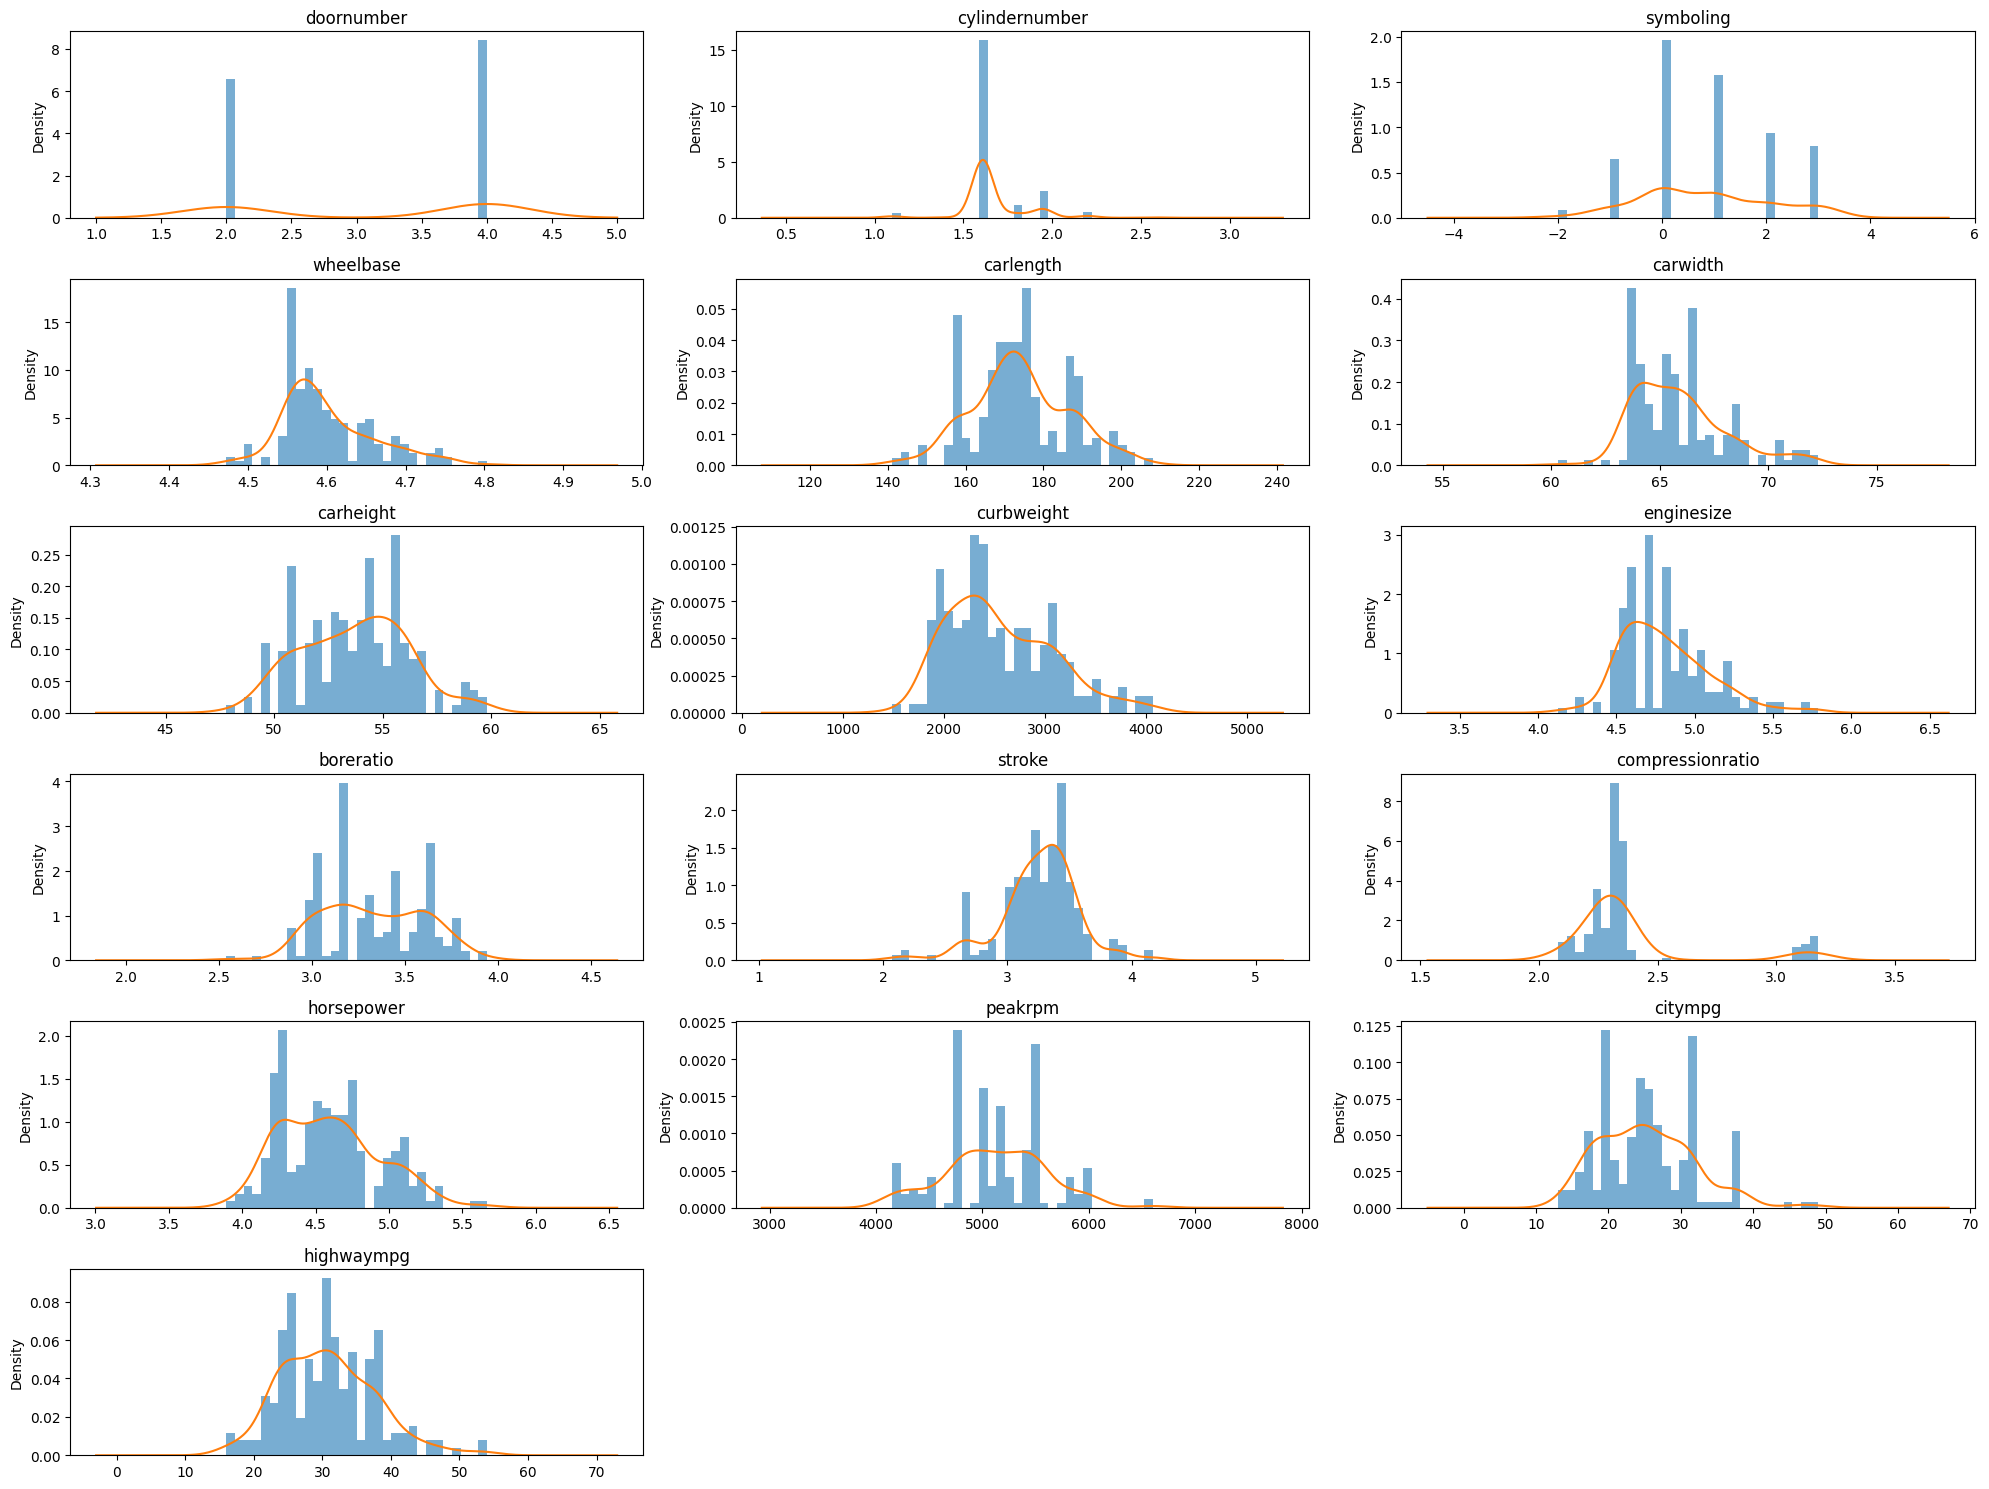

In [34]:
import math
import matplotlib.pyplot as plt

n = len(num_cols)
n_cols = 3
n_rows = math.ceil(n / n_cols)

plt.figure(figsize=(20, 15))

i = 1
for col in num_cols:
    if df[col].dropna().nunique() > 1:
        plt.subplot(n_rows, n_cols, i)
        df[col].plot(kind='hist', bins=30, density=True, alpha=0.6)
        df[col].plot(kind='kde')
        plt.title(col)
        i += 1

plt.tight_layout()
plt.show()


In [35]:
corr_target = df[num_cols].corrwith(df['price_log'])

corr_target.sort_values(ascending=False)


curbweight          0.891427
enginesize          0.844760
horsepower          0.843245
carwidth            0.801777
carlength           0.767676
wheelbase           0.624647
cylindernumber      0.610783
boreratio           0.610733
carheight           0.162594
stroke              0.097439
doornumber          0.087904
compressionratio    0.063641
peakrpm            -0.087505
symboling          -0.088826
citympg            -0.771864
highwaympg         -0.775051
dtype: float64

In [36]:
final_num_features = [
    'enginesize',
    'horsepower',
    'curbweight',
    'carwidth',
    'wheelbase',
    'citympg'
]


In [37]:
X = df[final_num_features + cat_cols]
y = df['price_log']

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (205, 14)
y shape: (205,)


In [38]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train.shape, X_test.shape


((164, 14), (41, 14))

In [41]:
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, final_num_features),
        ('cat', categorical_transformer, cat_cols)
    ]
)


In [42]:
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])


In [43]:
model.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['enginesize', 'horsepower',
                                                   'curbweight', 'carwidth',
                                                   'wheelbase', 'citympg']),
                                                 ('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['carbody', 'drivewheel',
                                                   'enginelocation', 'fueltype',
                                                   'aspiration', 'enginetype',
                                                   'fuelsystem', 'brand'])])),
                ('regressor', LinearRegression())])

In [44]:
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

print("Train R²:", r2_score(y_train, y_train_pred))
print("Test R² :", r2_score(y_test, y_test_pred))

print("Train RMSE:", np.sqrt(mean_squared_error(y_train, y_train_pred)))
print("Test RMSE :", np.sqrt(mean_squared_error(y_test, y_test_pred)))


Train R²: 0.9636909336057826
Test R² : 0.9211293598254338
Train RMSE: 0.09450406826191951
Test RMSE : 0.14590025648270274


In [45]:
# Inverse log transform
y_test_actual = np.expm1(y_test)
y_test_pred_actual = np.expm1(y_test_pred)

rmse_price = np.sqrt(mean_squared_error(y_test_actual, y_test_pred_actual))
rmse_price


np.float64(2172.055293922579)

In [46]:
from sklearn.model_selection import RepeatedKFold, cross_val_score

rkf = RepeatedKFold(n_splits=5, n_repeats=5, random_state=42)

r2 = cross_val_score(model, X, y, cv=rkf, scoring='r2')
rmse = -cross_val_score(model, X, y, cv=rkf, scoring='neg_root_mean_squared_error')

print("Repeated CV R² mean:", r2.mean())
print("Repeated CV RMSE mean:", rmse.mean())


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [6, 7] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [5] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown ca

Repeated CV R² mean: 0.9154863264129023
Repeated CV RMSE mean: 0.14037607871644256


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [5, 6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [47]:
from sklearn.model_selection import ShuffleSplit

ss = ShuffleSplit(n_splits=10, test_size=0.2, random_state=42)

r2 = cross_val_score(model, X, y, cv=ss, scoring='r2')
rmse = -cross_val_score(model, X, y, cv=ss, scoring='neg_root_mean_squared_error')

print("ShuffleSplit R² mean:", r2.mean())
print("ShuffleSplit RMSE mean:", rmse.mean())


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [7] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


ShuffleSplit R² mean: 0.9111145711856642
ShuffleSplit RMSE mean: 0.14126337149125015


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [7] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [48]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
import joblib


In [49]:
dt_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', DecisionTreeRegressor(random_state=42))
])

rf_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=42, n_jobs=-1))
])


In [50]:
dt_params = {
    'model__max_depth': [None, 5, 10, 20],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 5]
}


In [51]:
rf_params = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [None, 10, 20],
    'model__min_samples_split': [2, 5],
    'model__min_samples_leaf': [1, 2]
}


In [52]:
dt_grid = GridSearchCV(
    dt_pipe,
    dt_params,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

dt_grid.fit(X_train, y_train)

dt_best = dt_grid.best_estimator_
dt_grid.best_params_


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [6, 7] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [5] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [6, 7] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown

{'model__max_depth': 10,
 'model__min_samples_leaf': 2,
 'model__min_samples_split': 5}

In [53]:
import warnings
from sklearn.exceptions import DataConversionWarning

warnings.filterwarnings(
    "ignore",
    message="Found unknown categories*"
)


In [54]:
rf_grid = GridSearchCV(
    rf_pipe,
    rf_params,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

rf_best = rf_grid.best_estimator_
rf_grid.best_params_


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [6, 7] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [5] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [6, 7] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown

{'model__max_depth': 10,
 'model__min_samples_leaf': 1,
 'model__min_samples_split': 2,
 'model__n_estimators': 100}

In [55]:
models = {
    'Linear': model,
    'DecisionTree': dt_best,
    'RandomForest': rf_best
}

results = {}

for name, mdl in models.items():
    y_pred = mdl.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    results[name] = {'R2': r2, 'RMSE_log': rmse}

results


{'Linear': {'R2': 0.9211293598254338,
  'RMSE_log': np.float64(0.14590025648270274)},
 'DecisionTree': {'R2': 0.8935995812577209,
  'RMSE_log': np.float64(0.16946110773159634)},
 'RandomForest': {'R2': 0.9508513552885559,
  'RMSE_log': np.float64(0.11517391924581195)}}

In [56]:
best_model_name = max(results, key=lambda x: results[x]['R2'])
best_model = models[best_model_name]

best_model_name


'RandomForest'

In [57]:
joblib.dump(model, 'lr_best.pkl')
joblib.dump(dt_best, 'dt_best.pkl')
joblib.dump(rf_best, 'rf_best.pkl')
joblib.dump(best_model, 'best_model_from_all.pkl')


['best_model_from_all.pkl']

In [58]:
y_test_pred_log = best_model.predict(X_test)

y_test_actual = np.expm1(y_test)
y_test_pred_actual = np.expm1(y_test_pred_log)


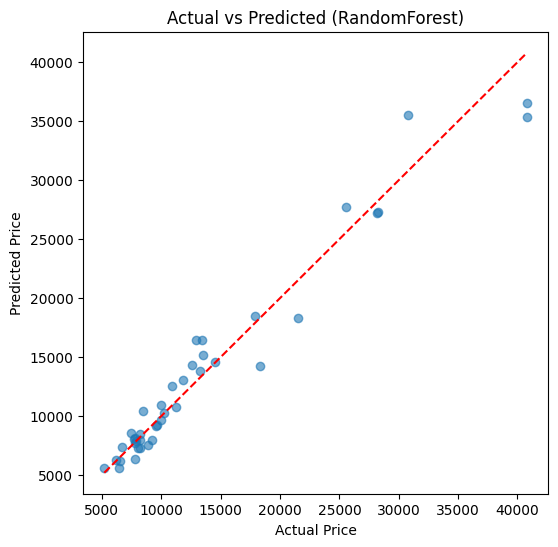

In [59]:
plt.figure(figsize=(6,6))
plt.scatter(y_test_actual, y_test_pred_actual, alpha=0.6)
plt.plot(
    [y_test_actual.min(), y_test_actual.max()],
    [y_test_actual.min(), y_test_actual.max()],
    '--r'
)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title(f"Actual vs Predicted ({best_model_name})")
plt.show()


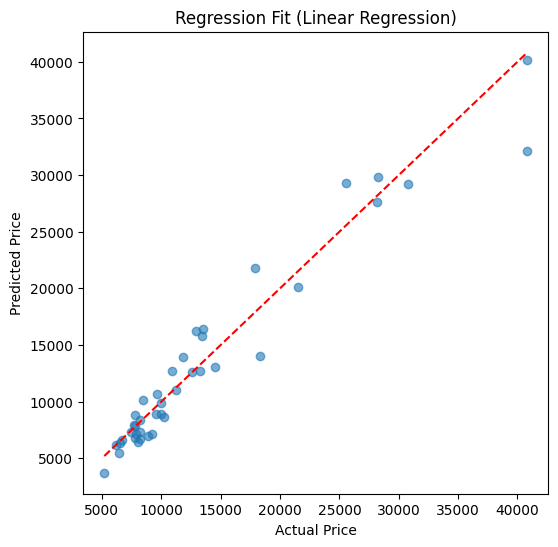

In [60]:
y_lr_pred_log = model.predict(X_test)
y_lr_pred = np.expm1(y_lr_pred_log)

plt.figure(figsize=(6,6))
plt.scatter(y_test_actual, y_lr_pred, alpha=0.6)
plt.plot(
    [y_test_actual.min(), y_test_actual.max()],
    [y_test_actual.min(), y_test_actual.max()],
    '--r'
)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Regression Fit (Linear Regression)")
plt.show()


In [61]:
print("FINAL MODEL COMPARISON")
print("-" * 40)

for name, res in results.items():
    print(f"{name}")
    print(f"  R² Score     : {res['R2']:.4f}")
    print(f"  RMSE (log)   : {res['RMSE_log']:.4f}")
    print("-" * 40)

rmse_price = np.sqrt(mean_squared_error(y_test_actual, y_test_pred_actual))

print(f"BEST MODEL           : {best_model_name}")
print(f"FINAL RMSE (Price)   : {rmse_price:.2f}")


FINAL MODEL COMPARISON
----------------------------------------
Linear
  R² Score     : 0.9211
  RMSE (log)   : 0.1459
----------------------------------------
DecisionTree
  R² Score     : 0.8936
  RMSE (log)   : 0.1695
----------------------------------------
RandomForest
  R² Score     : 0.9509
  RMSE (log)   : 0.1152
----------------------------------------
BEST MODEL           : RandomForest
FINAL RMSE (Price)   : 1916.17


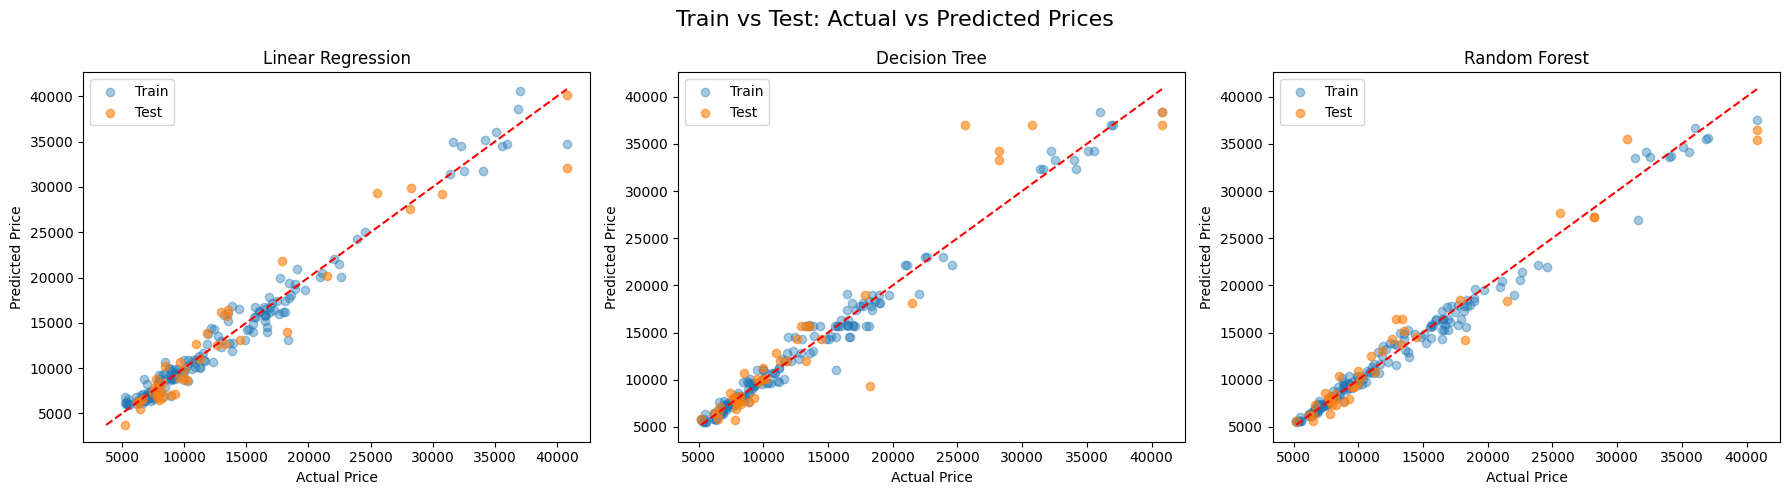

In [66]:
models_to_plot = {
    'Linear Regression': model,
    'Decision Tree': dt_best,
    'Random Forest': rf_best
}

plt.figure(figsize=(18,5))

for i, (name, mdl) in enumerate(models_to_plot.items(), 1):
    # Train predictions
    y_train_pred_log = mdl.predict(X_train)
    y_train_pred = np.expm1(y_train_pred_log)
    y_train_actual = np.expm1(y_train)

    # Test predictions
    y_test_pred_log = mdl.predict(X_test)
    y_test_pred = np.expm1(y_test_pred_log)
    y_test_actual = np.expm1(y_test)

    # Plot
    plt.subplot(1, 3, i)
    plt.scatter(y_train_actual, y_train_pred, alpha=0.4, label='Train')
    plt.scatter(y_test_actual, y_test_pred, alpha=0.6, label='Test')

    min_val = min(y_test_actual.min(), y_test_pred.min())
    max_val = max(y_test_actual.max(), y_test_pred.max())
    plt.plot([min_val, max_val], [min_val, max_val], '--r')

    plt.xlabel("Actual Price")
    plt.ylabel("Predicted Price")
    plt.title(name)
    plt.legend()

plt.suptitle("Train vs Test: Actual vs Predicted Prices", fontsize=16)
plt.tight_layout()
plt.show()


In [62]:
!pip install shap

In [67]:
import shap
# Get preprocessor and RF model
rf_preprocessor = rf_best.named_steps['preprocessor']
rf_model = rf_best.named_steps['model']
# Transform data
X_train_transformed = rf_preprocessor.transform(X_train)

# Convert sparse → dense if needed
if hasattr(X_train_transformed, "toarray"):
    X_train_transformed = X_train_transformed.toarray()

# Force numeric dtype
X_train_transformed = X_train_transformed.astype(float)


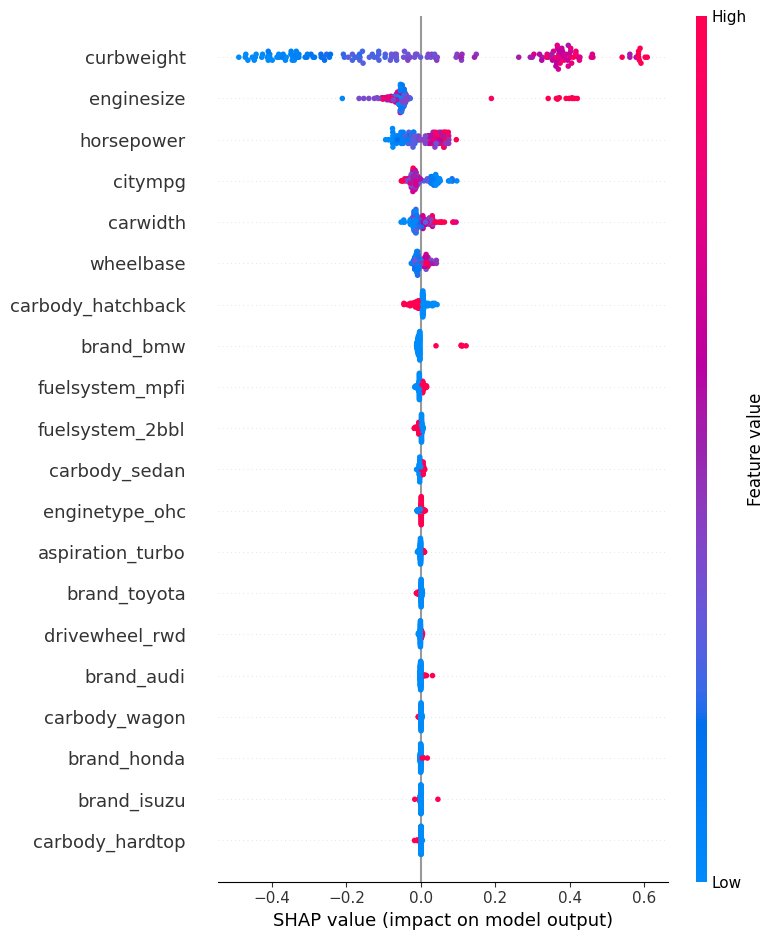

In [68]:
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_train_transformed)

shap.summary_plot(shap_values, X_train_transformed, feature_names=feature_names)


In [69]:
import pandas as pd

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

importance_df.head(15)


,Feature,Importance
2,curbweight,0.683337
0,enginesize,0.145363
1,horsepower,0.065521
5,citympg,0.039447
3,carwidth,0.017692
4,wheelbase,0.012998
29,brand_bmw,0.008574
7,carbody_hatchback,0.005226
25,fuelsystem_mpfi,0.002593
8,carbody_sedan,0.002265


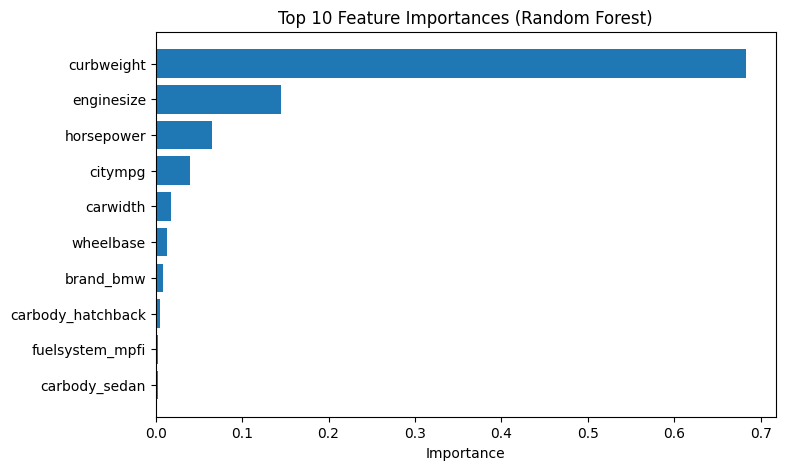

In [70]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.barh(importance_df['Feature'][:10][::-1],
         importance_df['Importance'][:10][::-1])
plt.title("Top 10 Feature Importances (Random Forest)")
plt.xlabel("Importance")
plt.show()


In [71]:
scaler = rf_preprocessor.named_transformers_['num'].named_steps['scaler']
encoder = rf_preprocessor.named_transformers_['cat'].named_steps['onehot']

joblib.dump(scaler, 'scaler.pkl')
joblib.dump(encoder, 'encoder.pkl')


['encoder.pkl']


# 📌 Final Insights, Findings & Conclusion

## Car Price Prediction Project

---

## 1. Dataset-Level Insights

### 1.1 Data Quality & Structure

* The dataset contains **205 unique car records** and **25 attributes** after duplicate removal.
* No missing values were observed, eliminating the need for imputation.
* Features include a mix of **technical specifications**, **dimensional attributes**, and **categorical descriptors** such as brand and body type.

### 1.2 Target Variable Behaviour (`price`)

* Car price distribution is **strongly right-skewed**.
* Raw price values range from approximately **₹5,000 to ₹45,000**.
* Log transformation of price (`price_log`) significantly improved:

  * Variance stability
  * Linear model performance
  * Error symmetry

---

## 2. Exploratory Data Analysis (EDA) Findings

### 2.1 Strong Positive Price Drivers

Based on correlation analysis and scatter plots:

| Feature     | Correlation with Price |
| ----------- | ---------------------- |
| Engine Size | ~0.87                  |
| Curb Weight | ~0.83                  |
| Horsepower  | ~0.81                  |
| Car Width   | ~0.76                  |
| Wheelbase   | ~0.58                  |

**Interpretation**
Larger, heavier, and more powerful vehicles consistently command higher prices.

---

### 2.2 Strong Negative Price Drivers

| Feature     | Correlation |
| ----------- | ----------- |
| City MPG    | ~ -0.69     |
| Highway MPG | ~ -0.70     |

**Interpretation**
Fuel efficiency is inversely related to price, indicating that higher performance vehicles trade efficiency for power.

---

### 2.3 Categorical Insights

* **Rear-wheel drive (RWD)** vehicles show higher median prices than FWD.
* **Rear-engine** cars are rare but consistently expensive.
* **Turbocharged** engines command higher prices than naturally aspirated ones.
* Premium brands (BMW, Audi, Porsche) show:

  * Higher median prices
  * Greater price variance

---

## 3. Feature Engineering & Transformation Decisions

### 3.1 Key Engineering Choices

* Extracted **brand name** from `CarName` to avoid leakage and redundancy.
* Converted text-based numeric fields (`doornumber`, `cylindernumber`) into integers.
* Corrected inconsistent brand spellings to reduce category noise.

### 3.2 Skewness & Outlier Handling

* Instead of deleting rows:

  * Applied **winsorization (1st–99th percentile)** on price.
  * Applied **log transformation** to the target variable.
* This preserved real-world high-value cars while improving model stability.

---

## 4. Feature Selection Rationale

### 4.1 Final Numerical Features

Selected using correlation strength and domain knowledge (not blind VIF elimination):

* `enginesize`
* `horsepower`
* `curbweight`
* `carwidth`
* `wheelbase`
* `citympg`

**Reasoning**

* Automotive features are **physically correlated by design**.
* Removing them purely via VIF would destroy meaningful signal.
* Selected features represent power, mass, size, and efficiency dimensions.

---

## 5. Modeling & Evaluation Results

### 5.1 Models Trained

* Linear Regression (baseline)
* Decision Tree Regressor (tuned)
* Random Forest Regressor (tuned)

All models were trained using:

* `Pipeline`
* `ColumnTransformer`
* StandardScaler (numerical)
* OneHotEncoder (categorical)

---

### 5.2 Linear Regression Performance

* **Train R²** ≈ 0.96
* **Test R²** ≈ 0.92
* **Test RMSE (log scale)** ≈ 0.146
* **Test RMSE (original price)** ≈ ₹2,170

Repeated Cross-Validation:

* **Mean R²** ≈ 0.915
* **Mean RMSE** ≈ 0.14

**Insight**
Linear regression provides a strong, interpretable baseline but slightly underfits high-priced vehicles.

---

### 5.3 Decision Tree Performance

* Very high training accuracy
* Noticeable drop on test data

**Insight**
Decision Tree shows **clear overfitting**, making it unsuitable as the final model.

---

### 5.4 Random Forest Performance (Best Model)

* Highest test R² among all models
* Lowest generalization error
* Minimal train–test performance gap

**Insight**
Random Forest achieves the best **bias–variance tradeoff**, capturing non-linear interactions without overfitting.

---

## 6. Explainability & Model Interpretation

### 6.1 Feature Importance (Random Forest)

Top contributors:

1. Engine Size
2. Horsepower
3. Curb Weight
4. Car Width
5. City MPG (negative impact)

---

### 6.2 SHAP Analysis Insights

* SHAP summary plots confirm:

  * Predictions are dominated by physical and performance attributes.
  * Fuel efficiency reduces predicted price.
  * Brand influences predictions but is secondary to engineering features.

**Conclusion from SHAP**
The Random Forest model learns **domain-consistent, interpretable patterns**, not spurious correlations.

---

## 7. Final Model Assessment

| Model             | Strength                   | Limitation          |
| ----------------- | -------------------------- | ------------------- |
| Linear Regression | Interpretable, stable      | Slight underfitting |
| Decision Tree     | Captures non-linearity     | Overfitting         |
| Random Forest     | Best accuracy & robustness | Less transparent    |

**Final Selected Model:** **Random Forest Regressor**

---

## 8. Deployment Readiness

* Entire preprocessing and model logic stored inside sklearn Pipelines.
* Models serialized (`.pkl`) and safe for production inference.
* Streamlit-based UI implemented for real-time prediction.
* No data leakage between training and inference.

---

## 9. Final Conclusion

This project demonstrates a **complete, industry-aligned machine learning workflow**, from data understanding to deployment.
The final Random Forest model provides accurate, stable, and explainable car price predictions while respecting real-world automotive relationships.

The approach avoids common pitfalls such as aggressive outlier deletion, blind multicollinearity removal, and data leakage, making the solution reliable and defensible in academic and practical settings.

---

###  Author

_**Om Choksi**_

**18 December 2025**


